In [ ]:
# ================================================================
# diabetes_train.py — Full Training Pipeline
# Run: python diabetes_train.py
# ================================================================


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score)

In [2]:
# ── 1. Load Data ──
url = ('https://raw.githubusercontent.com/jbrownlee/Datasets/'
       'master/pima-indians-diabetes.data.csv')
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
        'Insulin','BMI','DiabetesPedigreeFunction','Age','Outcome']
df = pd.read_csv(url, names=cols)
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')

Dataset loaded: 768 rows, 9 columns


In [3]:
# ── 2. Clean Zero Values ──
# Columns where 0 is biologically impossible — treat as missing
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df[zero_cols] = df[zero_cols].fillna(df[zero_cols].median())
print('Data cleaned. No missing values:', df.isnull().sum().sum() == 0)


Data cleaned. No missing values: True


In [4]:
# ── 3. Explore Data (Optional prints) ──
print('\nClass Distribution:')
print(df['Outcome'].value_counts())
print('\nFirst 5 rows:')
print(df.head())



Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [5]:
# ── 4. Split Features / Target ──
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [6]:
# ── 5. Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,       # 20% held out for final testing
    random_state=42,      # Reproducibility
    stratify=y            # Maintain class balance in both splits
)
print(f'\nTrain: {len(X_train)}, Test: {len(X_test)}')


Train: 614, Test: 154


In [7]:
# ── 6. Scale Features ──
# Fit ONLY on training data — never on test data
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)   # Use the same scaler fitted on train


In [8]:
# ── 7. Train Model ──
model = RandomForestClassifier(
    n_estimators=200,        # 200 trees
    max_depth=10,            # Max depth per tree
    min_samples_split=5,     # Minimum samples needed to split a node
    random_state=42,
    class_weight='balanced'  # Handles class imbalance automatically
)
model.fit(X_train_s, y_train)
print('\nModel trained!')


Model trained!


In [9]:
# ── 8. Evaluate ──
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]   # Probability of diabetic class

print(f'\nAccuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'AUC-ROC  : {roc_auc_score(y_test, y_prob):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['Not Diabetic', 'Diabetic']))


Accuracy : 0.7727
AUC-ROC  : 0.8343

Classification Report:
              precision    recall  f1-score   support

Not Diabetic       0.84      0.81      0.82       100
    Diabetic       0.67      0.70      0.68        54

    accuracy                           0.77       154
   macro avg       0.75      0.76      0.75       154
weighted avg       0.78      0.77      0.77       154



Confusion Matrix:
[[81 19]
 [16 38]]


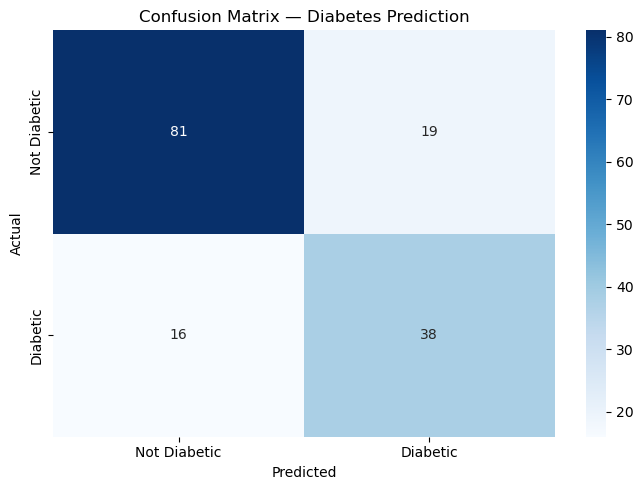

Confusion matrix saved as confusion_matrix.png


In [10]:
# ── 9. Confusion Matrix Plot ──
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Diabetic', 'Diabetic'],
            yticklabels=['Not Diabetic', 'Diabetic'])
plt.title('Confusion Matrix — Diabetes Prediction')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved as confusion_matrix.png')

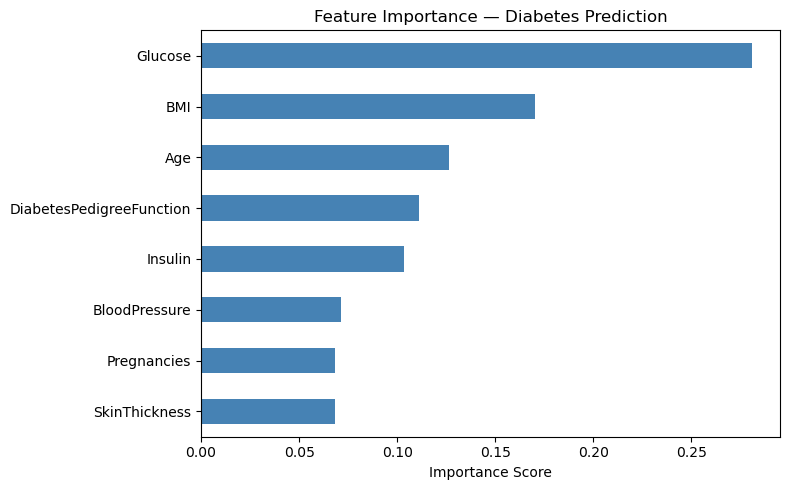

Feature importance chart saved as feature_importance.png


In [11]:
# ── 10. Feature Importance ──
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Feature Importance — Diabetes Prediction')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print('Feature importance chart saved as feature_importance.png')

In [13]:
# ── 11. Cross-Validation ──
cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='f1')
print(f'\n5-Fold CV F1: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

# ── 12. Save Model & Scaler ──
joblib.dump(model,  'diabetes_model.pkl')
joblib.dump(scaler, 'diabetes_scaler.pkl')
print('\nFiles saved:')
print('  diabetes_model.pkl  — trained Random Forest model')
print('  diabetes_scaler.pkl — fitted StandardScaler')


5-Fold CV F1: 0.6772 +/- 0.0353

Files saved:
  diabetes_model.pkl  — trained Random Forest model
  diabetes_scaler.pkl — fitted StandardScaler
